In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_2/FIRST-J110949.3+124614_2_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_2/FIRST-J110949.3+124614_2_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 964)   float32   


In [4]:
image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]

Text(0.5, 0, 'wavelength')

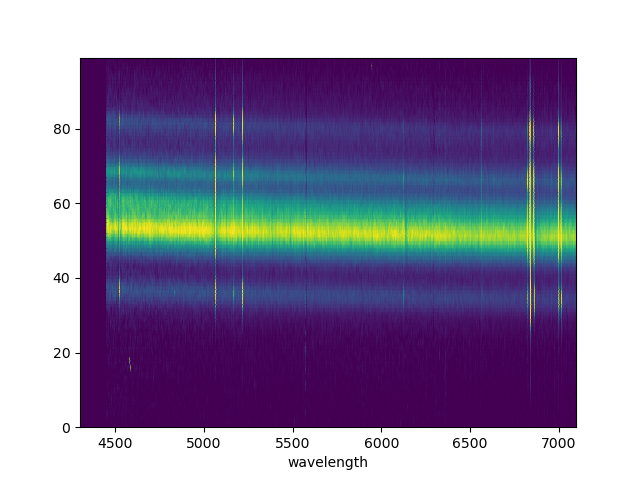

In [5]:
wavelengths = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelengths, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

In [6]:
z = 0.04263
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_2/PSF/Real_seeing_FIRST_2.txt")
sigma = seeing[0] / 2.35

In [7]:
l_HA

6842.78069

Text(0.5, 1.0, 'H$\\alpha$')

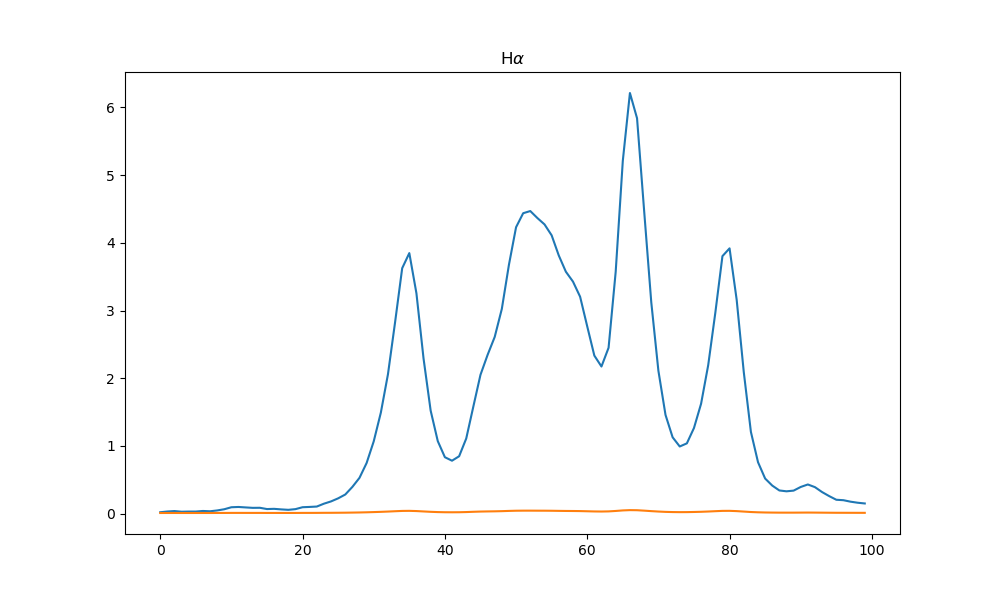

In [8]:
#Ogni punto del flusso è il risultato della somma di 20 lunghezze d'onda 
mask_HA = (wavelengths > l_HA-8)*(wavelengths < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [9]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

#Define the function for the aic
#Per l'AIC test usiamo il chi quadro perchè il numero di conteggi è elevato (S/N grande) 
#quindi Poisson --> Gauss
#def chi_quad(x, y, y_err, params):
#    return np.sum((((y - model_convolved(x, *params)) / y_err)**2))
    
def AIC(x, y, chi, params): #k=number of model parameter, N=number of data points
    return chi + 2*len(params) +((2*len(params)*(len(params)+1))/(len(y)-len(params)-1))

def BIC(x, y, chi, params):
        return chi + len(params)*np.log(len(y))
    
def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def save_params(params_curve, covariance, radial_profile, radial_profile_error, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, chi2

In [10]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params) 
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 38),  # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params1 = result.x

print("Optimize parameters with differential_evolution:", best_params1)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 346.1207687601697
differential_evolution step 2: f(x)= 259.45819603958074
differential_evolution step 3: f(x)= 259.45819603958074
differential_evolution step 4: f(x)= 241.7296935858784
differential_evolution step 5: f(x)= 238.10611226917587
differential_evolution step 6: f(x)= 238.10611226917587
differential_evolution step 7: f(x)= 238.10611226917587
differential_evolution step 8: f(x)= 238.10611226917587
differential_evolution step 9: f(x)= 235.7542872460477
differential_evolution step 10: f(x)= 235.7542872460477
differential_evolution step 11: f(x)= 235.7542872460477
differential_evolution step 12: f(x)= 234.6837109685235
differential_evolution step 13: f(x)= 233.2181483077139
differential_evolution step 14: f(x)= 233.2181483077139
differential_evolution step 15: f(x)= 233.2181483077139
differential_evolution step 16: f(x)= 233.2181483077139
differential_evolution step 17: f(x)= 232.69258039597705
differential_evolution step 18: f(x)= 232.69258039

Optimize parameters with curve fit:
Sérsic 1: I_e=1.4925, r_e=18.6685, n=0.5956, x_0=57.9656
[0.19508016 1.20673171 0.09393007 0.87846587]
738.4131272456752
746.8341798772542 0.0 756.8338079896276 4


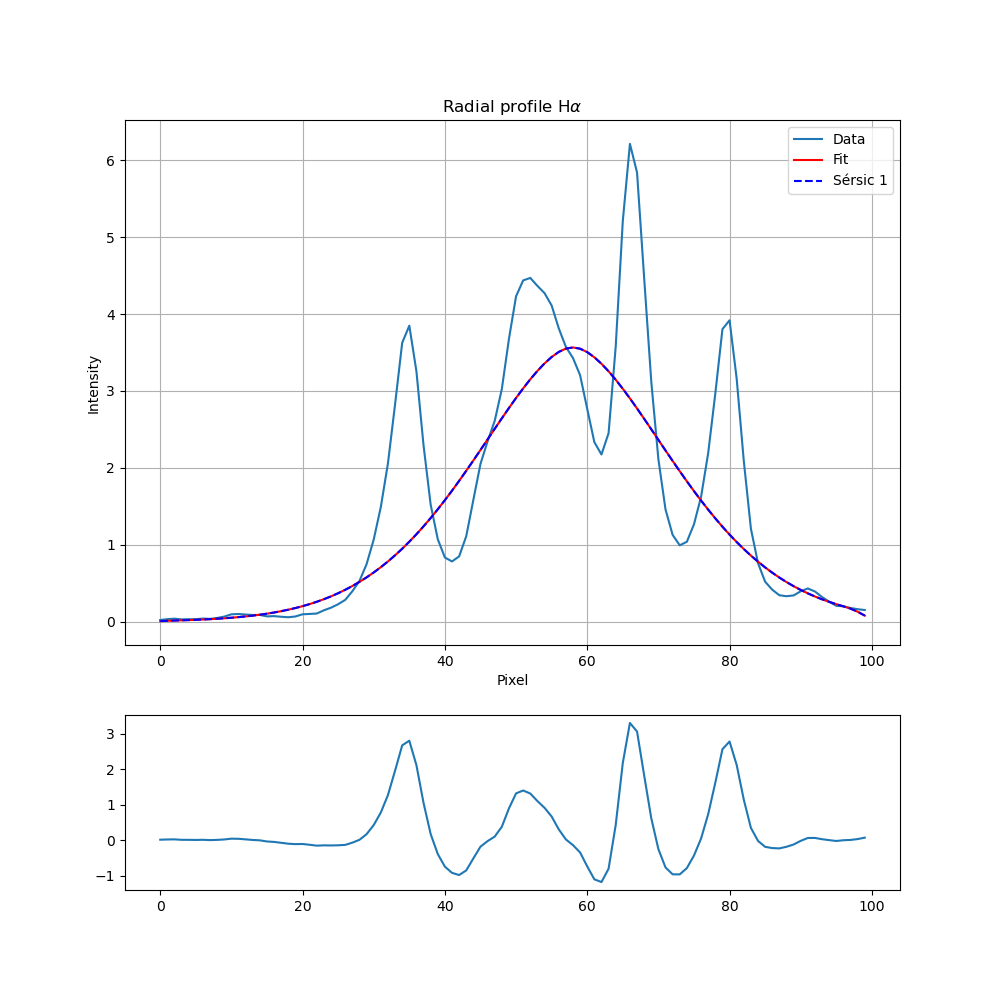

In [11]:
aic = np.zeros(7)
bic = np.zeros(7)
chi_quadr = np.zeros(7)
chi_quadro = np.zeros(7)
red_chi = np.zeros(7)

params_curve_1, covariance_1 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params1,
                                         sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[0], red_chi[0] = save_params(params_curve_1, covariance_1, radial_profile_HA, radial_profile_error_HA, x_axes, 1, line_name="One", 
                                           output_prefix="fit")

aic[0] = AIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
bic[0] = BIC(x_axes, radial_profile_HA, chi_quadr[0], params_curve_1)
print(aic[0], chi_quadro[0], bic[0], len(params_curve_1))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_1)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_1), 'b--', label='Sérsic 1')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_1', bbox_inches='tight')

In [12]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =  [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 38),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 55),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params2 = result.x

print("Optimize parameters with differential_evolution:", best_params2)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 223.04476277272002
differential_evolution step 2: f(x)= 173.4893575148779
differential_evolution step 3: f(x)= 173.4893575148779
differential_evolution step 4: f(x)= 173.4893575148779
differential_evolution step 5: f(x)= 173.4893575148779
differential_evolution step 6: f(x)= 165.1804909535632
differential_evolution step 7: f(x)= 165.1804909535632
differential_evolution step 8: f(x)= 165.1804909535632
differential_evolution step 9: f(x)= 165.1804909535632
differential_evolution step 10: f(x)= 159.41970069244286
differential_evolution step 11: f(x)= 154.35257696784845
differential_evolution step 12: f(x)= 149.02679836836683
differential_evolution step 13: f(x)= 114.4466173276391
differential_evolution step 14: f(x)= 114.4466173276391
differential_evolution step 15: f(x)= 114.4466173276391
differential_evolution step 16: f(x)= 114.4466173276391
differential_evolution step 17: f(x)= 107.58749162993767
differential_evolution step 18: f(x)= 104.9188362124

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_14004\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_14004\3541758431.py:8: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=2.3958, r_e=1.8203, n=0.3031, x_0=34.2069
Sérsic 2: I_e=1.4988, r_e=17.4948, n=0.5999, x_0=59.0507
[3.01238479 0.53773941 1.07597728 0.38100262 0.18120475 1.11739769
 0.08463478 0.8114727 ]
543.6188145107793
561.201232093197 543.6188145107793 580.460175998684 8


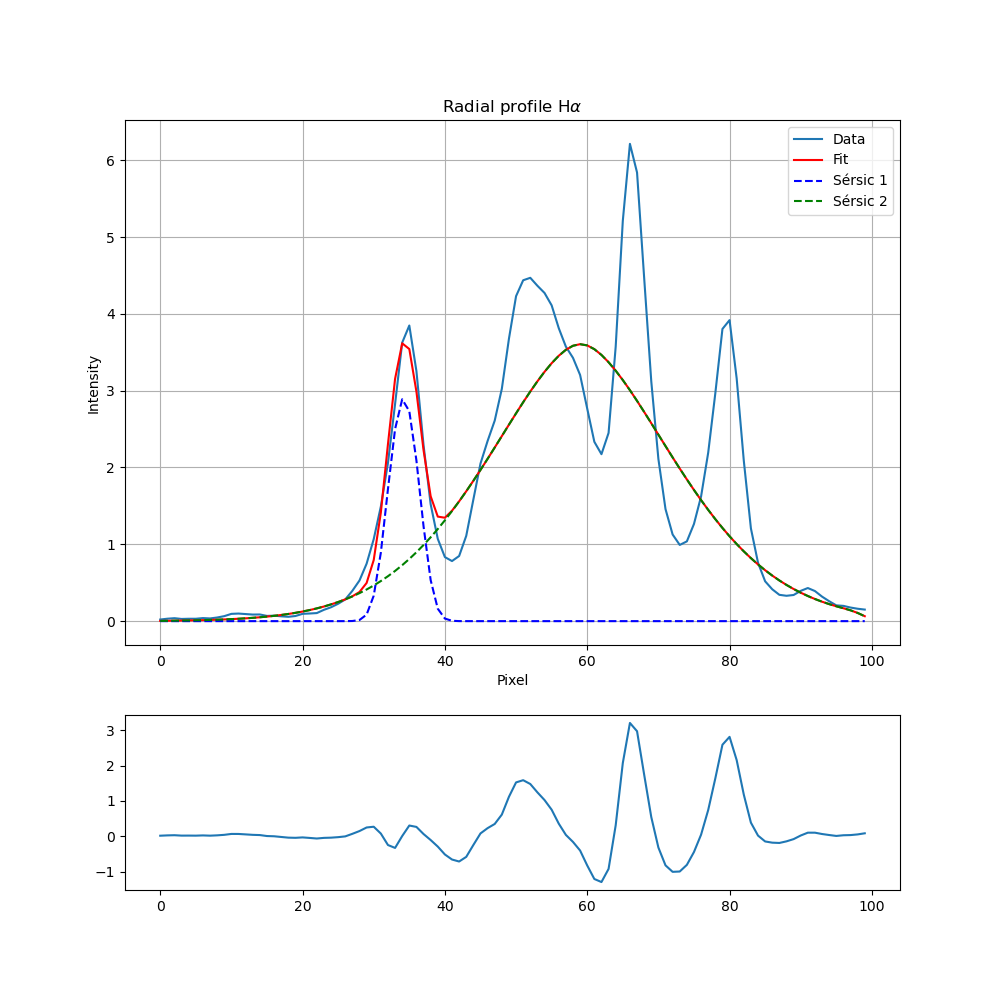

In [13]:
# Plots:
params_curve_2, covariance_2 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params2, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[1], red_chi[1] = save_params(params_curve_2, covariance_2, radial_profile_HA, radial_profile_error_HA,
    x_axes, 2, line_name="Two", output_prefix="fit")

aic[1] = AIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
bic[1] = BIC(x_axes, radial_profile_HA, chi_quadr[1], params_curve_2)
print(aic[1], chi_quadr[1], bic[1], len(params_curve_2))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_2)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_2[4:8]), 'g--', label='Sérsic 2')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_2', bbox_inches='tight')

In [14]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 38),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 55),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (60, 70),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params3 = result.x

print("Optimize parameters with differential_evolution:", best_params3)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 5758.145835411087
differential_evolution step 2: f(x)= 982.9435861413577
differential_evolution step 3: f(x)= 208.64159234318006
differential_evolution step 4: f(x)= 135.37629969048848
differential_evolution step 5: f(x)= 96.06338249047332
differential_evolution step 6: f(x)= 96.06338249047332
differential_evolution step 7: f(x)= 96.06338249047332
differential_evolution step 8: f(x)= 96.06338249047332
differential_evolution step 9: f(x)= 96.06338249047332
differential_evolution step 10: f(x)= 96.06338249047332
differential_evolution step 11: f(x)= 96.06338249047332
differential_evolution step 12: f(x)= 96.06338249047332
differential_evolution step 13: f(x)= 96.06338249047332
differential_evolution step 14: f(x)= 77.85802976674273
differential_evolution step 15: f(x)= 77.85802976674273
differential_evolution step 16: f(x)= 77.85802976674273
differential_evolution step 17: f(x)= 77.85802976674273
differential_evolution step 18: f(x)= 77.85802976674273

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_14004\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_14004\429783234.py:9: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=1.0921, r_e=3.4059, n=0.9389, x_0=34.5393
Sérsic 2: I_e=2.4383, r_e=5.1097, n=0.3388, x_0=52.0795
Sérsic 3: I_e=0.0729, r_e=69.4994, n=2.8977, x_0=66.2476
[6.83617343e-01 1.12860526e+00 5.11078817e-01 2.76943012e-01
 4.43695123e-01 4.54256754e-01 1.31247165e-01 4.04404369e-01
 1.11681111e-01 7.08432722e+01 1.44823968e+00 4.73793172e-03]
316.5140861615799
344.1002930581316 316.5140861615799 371.776128393437 12


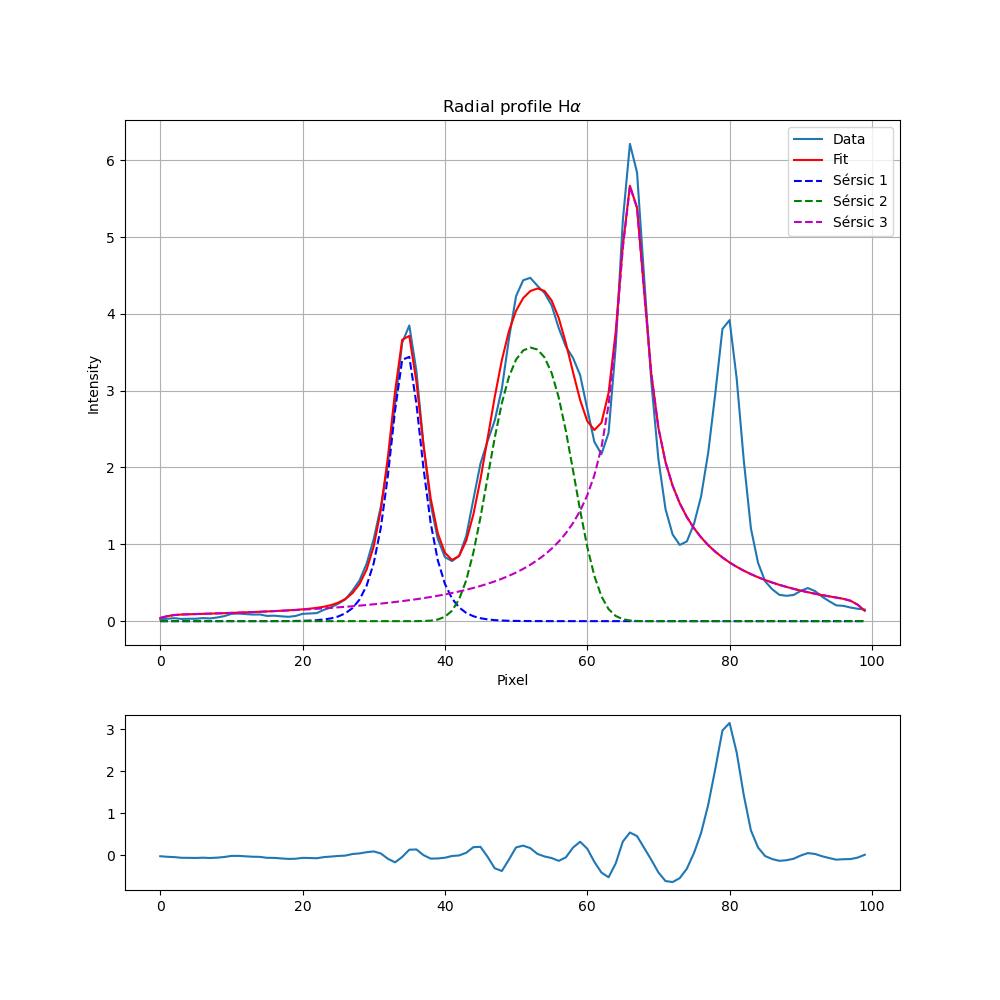

In [15]:
# Plots:
params_curve_3, covariance_3 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params3, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[2], red_chi[2] = save_params(params_curve_3, covariance_3, radial_profile_HA, radial_profile_error_HA,x_axes, 3,  
                                       line_name="Three", output_prefix="fit")

aic[2] = AIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
bic[2] = BIC(x_axes, radial_profile_HA, chi_quadr[2], params_curve_3)
print(aic[2], chi_quadr[2], bic[2], len(params_curve_3))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_3)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_3[8:12]), 'm--', label='Sérsic 3')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_3', bbox_inches='tight')

In [16]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 38),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 55),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (72, 82),   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params4 = result.x

print("Optimize parameters with differential_evolution:", best_params4)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 1182.0864396709421
differential_evolution step 2: f(x)= 1182.0864396709421
differential_evolution step 3: f(x)= 1182.0864396709421
differential_evolution step 4: f(x)= 1182.0864396709421
differential_evolution step 5: f(x)= 1182.0864396709421
differential_evolution step 6: f(x)= 1182.0864396709421
differential_evolution step 7: f(x)= 1182.0864396709421
differential_evolution step 8: f(x)= 1182.0864396709421
differential_evolution step 9: f(x)= 1182.0864396709421
differential_evolution step 10: f(x)= 413.83716244193823
differential_evolution step 11: f(x)= 413.83716244193823
differential_evolution step 12: f(x)= 413.83716244193823
differential_evolution step 13: f(x)= 413.83716244193823
differential_evolution step 14: f(x)= 413.83716244193823
differential_evolution step 15: f(x)= 413.83716244193823
differential_evolution step 16: f(x)= 222.81032394890056
differential_evolution step 17: f(x)= 179.64556315708364
differential_evolution step 18: f(x)= 17

Optimize parameters with curve fit:
Sérsic 1: I_e=0.9353, r_e=3.9222, n=1.0612, x_0=34.5419
Sérsic 2: I_e=2.4830, r_e=5.5514, n=0.3700, x_0=52.4715
Sérsic 3: I_e=0.0195, r_e=120.8682, n=4.1393, x_0=66.3466
Sérsic 4: I_e=1.7291, r_e=2.0588, n=0.6738, x_0=79.5663
[1.34659461e-01 3.21502428e-01 1.17084325e-01 6.38267700e-02
 1.00668520e-01 1.14537509e-01 2.82603886e-02 9.42312637e-02
 1.98774506e-02 7.99616729e+01 1.04401804e+00 1.16706813e-04
 3.60084219e-01 1.87212946e-01 1.76633096e-01 5.97400180e-02]
16.39560620580722
54.9498230732771 16.39560620580722 90.07832918161668 16


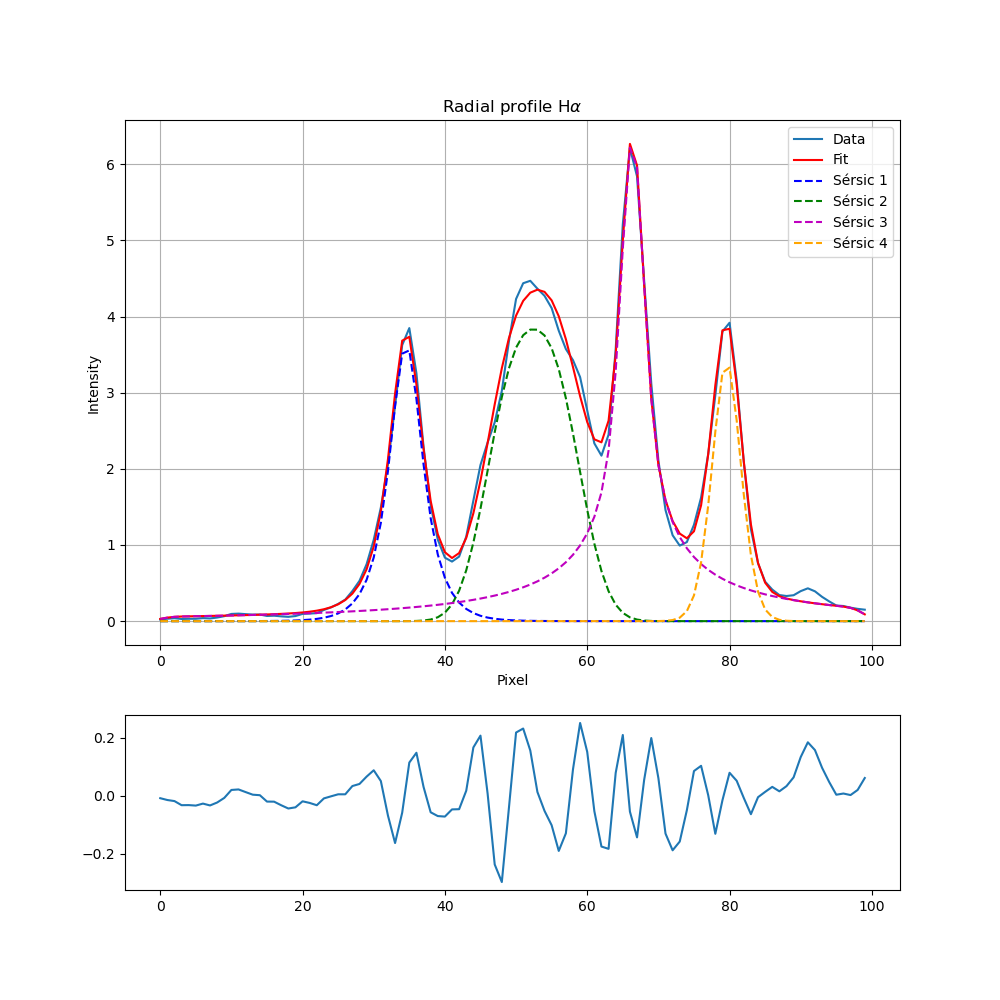

In [17]:
# Plots:
params_curve_4, covariance_4 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params4, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[3], red_chi[3] = save_params(params_curve_4, covariance_4, radial_profile_HA, radial_profile_error_HA, x_axes, 4, line_name="Four", output_prefix="fit")

aic[3] = AIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
bic[3] = BIC(x_axes, radial_profile_HA, chi_quadr[3], params_curve_4)
print(aic[3], chi_quadr[3], bic[3], len(params_curve_4))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_4)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_4[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)

plt.savefig('AIC_4', bbox_inches='tight')

In [18]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 38),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 55),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (72, 82), 

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 60)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params5 = result.x

print("Optimize parameters with differential_evolution:", best_params5)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 36652.05215278741
differential_evolution step 2: f(x)= 18997.904179774054
differential_evolution step 3: f(x)= 6130.95317750526
differential_evolution step 4: f(x)= 4055.776417727116
differential_evolution step 5: f(x)= 3843.3888745083186
differential_evolution step 6: f(x)= 1241.8463977063216
differential_evolution step 7: f(x)= 1059.1117327605461
differential_evolution step 8: f(x)= 1059.1117327605461
differential_evolution step 9: f(x)= 1034.1917530303447
differential_evolution step 10: f(x)= 1034.1917530303447
differential_evolution step 11: f(x)= 1034.1917530303447
differential_evolution step 12: f(x)= 1034.1917530303447
differential_evolution step 13: f(x)= 1034.1917530303447
differential_evolution step 14: f(x)= 1034.1917530303447
differential_evolution step 15: f(x)= 637.0984019131074
differential_evolution step 16: f(x)= 637.0984019131074
differential_evolution step 17: f(x)= 635.4890716605238
differential_evolution step 18: f(x)= 635.48907

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_14004\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_14004\2951490982.py:11: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.8571, r_e=4.1605, n=1.1296, x_0=34.5346
Sérsic 2: I_e=2.2497, r_e=5.2092, n=0.4263, x_0=51.8322
Sérsic 3: I_e=0.3111, r_e=8.5967, n=2.3710, x_0=66.3620
Sérsic 4: I_e=0.0819, r_e=15.5948, n=3.1210, x_0=79.5475
Sérsic 5: I_e=0.0136, r_e=117.1408, n=2.9656, x_0=58.8702
[1.77517345e-01 6.77200025e-01 1.64436213e-01 7.29579546e-02
 1.63979355e-01 3.71056535e-01 4.40686839e-02 3.26130368e-01
 3.15287116e-01 7.06348835e+00 7.73197614e-01 6.44058783e-02
 6.77465345e-02 9.81843466e+00 6.73455857e-01 6.52674816e-02
 1.10660567e-01 6.23235389e+02 6.18153210e+00 1.34070232e-02]
18.476203150379305
69.10911454278437 18.476203150379305 110.57960687014115 20


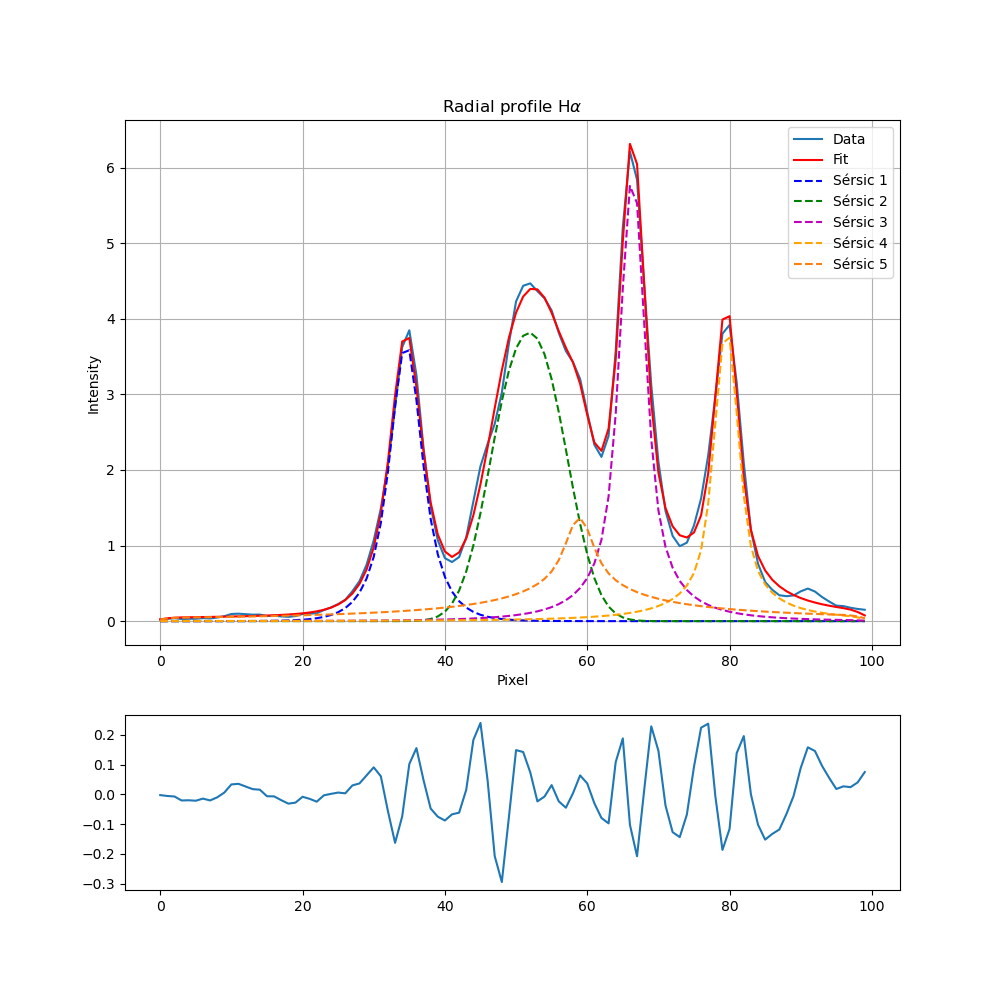

In [19]:
# Plots:
params_curve_5, covariance_5 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params5, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[4], red_chi[4] = save_params(params_curve_5, covariance_5, radial_profile_HA, radial_profile_error_HA, x_axes, 5, line_name="Five", output_prefix="fit")

aic[4] = AIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
bic[4] = BIC(x_axes, radial_profile_HA, chi_quadr[4], params_curve_5)
print(aic[4], chi_quadr[4], bic[4], len(params_curve_5))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_5)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_5[16:20]),  linestyle='--', label='Sérsic 5')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
#ax[1].set_ylim(-0.2, 0.2)
plt.savefig('AIC_5', bbox_inches='tight')

In [26]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
      (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 38),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 55),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (72, 82), 

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 60),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (90, 93)   # x_0: posizione da 0 a 100
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params6 = result.x

print("Optimize parameters with differential_evolution:", best_params6)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 62545.66593436491
differential_evolution step 2: f(x)= 62545.66593436491
differential_evolution step 3: f(x)= 36103.1531865906
differential_evolution step 4: f(x)= 36103.1531865906
differential_evolution step 5: f(x)= 36103.1531865906
differential_evolution step 6: f(x)= 36103.1531865906
differential_evolution step 7: f(x)= 33658.16067585523
differential_evolution step 8: f(x)= 28645.814095566537
differential_evolution step 9: f(x)= 28645.814095566537
differential_evolution step 10: f(x)= 10199.812852183766
differential_evolution step 11: f(x)= 10199.812852183766
differential_evolution step 12: f(x)= 4019.073641677191
differential_evolution step 13: f(x)= 4019.073641677191
differential_evolution step 14: f(x)= 4019.073641677191
differential_evolution step 15: f(x)= 4019.073641677191
differential_evolution step 16: f(x)= 3335.9596339281243
differential_evolution step 17: f(x)= 3335.9596339281243
differential_evolution step 18: f(x)= 1972.534257345184

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_14004\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_14004\2084913344.py:12: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.8182, r_e=4.2409, n=1.1656, x_0=34.5256
Sérsic 2: I_e=2.1413, r_e=5.0580, n=0.4349, x_0=51.6376
Sérsic 3: I_e=0.6435, r_e=5.0436, n=1.7851, x_0=66.3860
Sérsic 4: I_e=1.7723, r_e=2.0946, n=0.6465, x_0=79.4785
Sérsic 5: I_e=0.0753, r_e=39.0949, n=1.9910, x_0=58.5979
Sérsic 6: I_e=0.2056, r_e=11.3589, n=0.1629, x_0=81.9092
[1.40378011e-01 6.21443863e-01 1.35981906e-01 6.18582273e-02
 1.91380169e-01 4.20233999e-01 4.07743157e-02 3.44157591e-01
 5.34917347e-01 2.22411234e+00 6.12525076e-01 5.72408371e-02
 3.24410552e-01 1.91126621e-01 1.52566697e-01 6.19327500e-02
 1.82956708e-01 4.71525501e+01 1.67456343e+00 6.63297920e-02
 5.50226048e-02 2.18156811e+01 3.28987373e-01 2.57989765e+01]
11.264477552576743
75.26447755257675 11.264477552576743 121.78856201629094 24


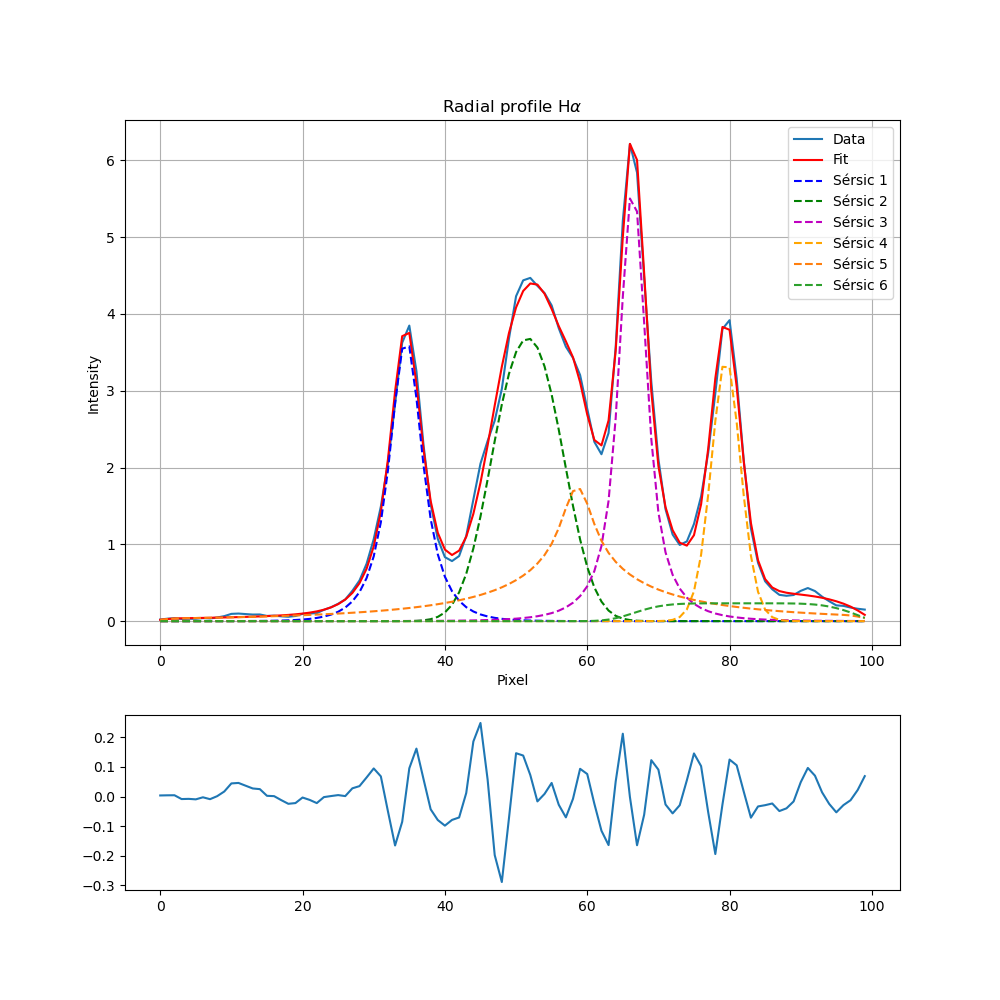

In [27]:
# Plots:
params_curve_6, covariance_6 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params6, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[5], red_chi[5] = save_params(params_curve_6, covariance_6, radial_profile_HA, radial_profile_error_HA, x_axes, 6,
                                       line_name="Six", output_prefix="fit")

aic[5] = AIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
bic[5] = BIC(x_axes, radial_profile_HA, chi_quadr[5], params_curve_6)
print(aic[5], chi_quadr[5], bic[5], len(best_params6))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_6)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_6[20:24]),  linestyle='--', label='Sérsic 6')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_6', bbox_inches='tight')

In [28]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24]) +
        sersic_1d(x_hr, *params[24:28])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs): #per diff evolution
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds =[
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (28, 38),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (45, 55),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (72, 82), 

    (0, 10),
    (0, 50),
    (0.1, 10),
    (55, 60),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (90, 93),   # x_0: posizione da 0 a 100

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (0, 100)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params7 = result.x

print("Optimize parameters with differential_evolution:", best_params7)

print("Chi quadro minimo:", result.fun)

differential_evolution step 1: f(x)= 528192.8199848966
differential_evolution step 2: f(x)= 134755.51753611228
differential_evolution step 3: f(x)= 71353.91241073214
differential_evolution step 4: f(x)= 42369.395964467236
differential_evolution step 5: f(x)= 29004.989085527013
differential_evolution step 6: f(x)= 24740.842337428036
differential_evolution step 7: f(x)= 24740.842337428036
differential_evolution step 8: f(x)= 24740.842337428036
differential_evolution step 9: f(x)= 24740.842337428036
differential_evolution step 10: f(x)= 24740.842337428036
differential_evolution step 11: f(x)= 16727.841564863873
differential_evolution step 12: f(x)= 16727.841564863873
differential_evolution step 13: f(x)= 16727.841564863873
differential_evolution step 14: f(x)= 8400.471668240816
differential_evolution step 15: f(x)= 8400.471668240816
differential_evolution step 16: f(x)= 8400.471668240816
differential_evolution step 17: f(x)= 8400.471668240816
differential_evolution step 18: f(x)= 8400.471

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_14004\111436280.py:9: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_14004\949711089.py:13: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_14004\111436280.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with curve fit:
Sérsic 1: I_e=0.6621, r_e=5.3211, n=1.3157, x_0=34.6124
Sérsic 2: I_e=2.3135, r_e=5.5076, n=0.3695, x_0=53.1889
Sérsic 3: I_e=1.9411, r_e=2.3171, n=0.9545, x_0=66.4016
Sérsic 4: I_e=1.2576, r_e=2.4501, n=0.9817, x_0=79.7112
Sérsic 5: I_e=0.0091, r_e=0.0057, n=4.3637, x_0=98.8266
Sérsic 6: I_e=0.0100, r_e=189.4595, n=2.1184, x_0=90.3360
Sérsic 7: I_e=0.0484, r_e=18.4467, n=0.0266, x_0=60.4940
[8.60587330e-02 4.43980683e-01 1.03364066e-01 4.80944739e-02
 2.00568619e-01 2.00168116e-01 3.95695465e-02 1.30593542e-01
 6.93225315e-01 5.74868753e-01 2.84296382e-01 4.71118823e-02
 4.98837069e-01 3.47670009e-01 2.54518454e-01 3.76112812e-01
 2.07521891e+03 1.56435655e+03 1.25787057e+06 6.98204918e+01
 1.38689942e-02 2.05849257e+02 8.64008445e-01 8.45743756e-01
 5.54431506e-01 2.17115163e+00 5.53106721e-02 2.33604759e+00]
9.152405364170884
88.02564480079062 9.152405364170884 138.09717057183744 28


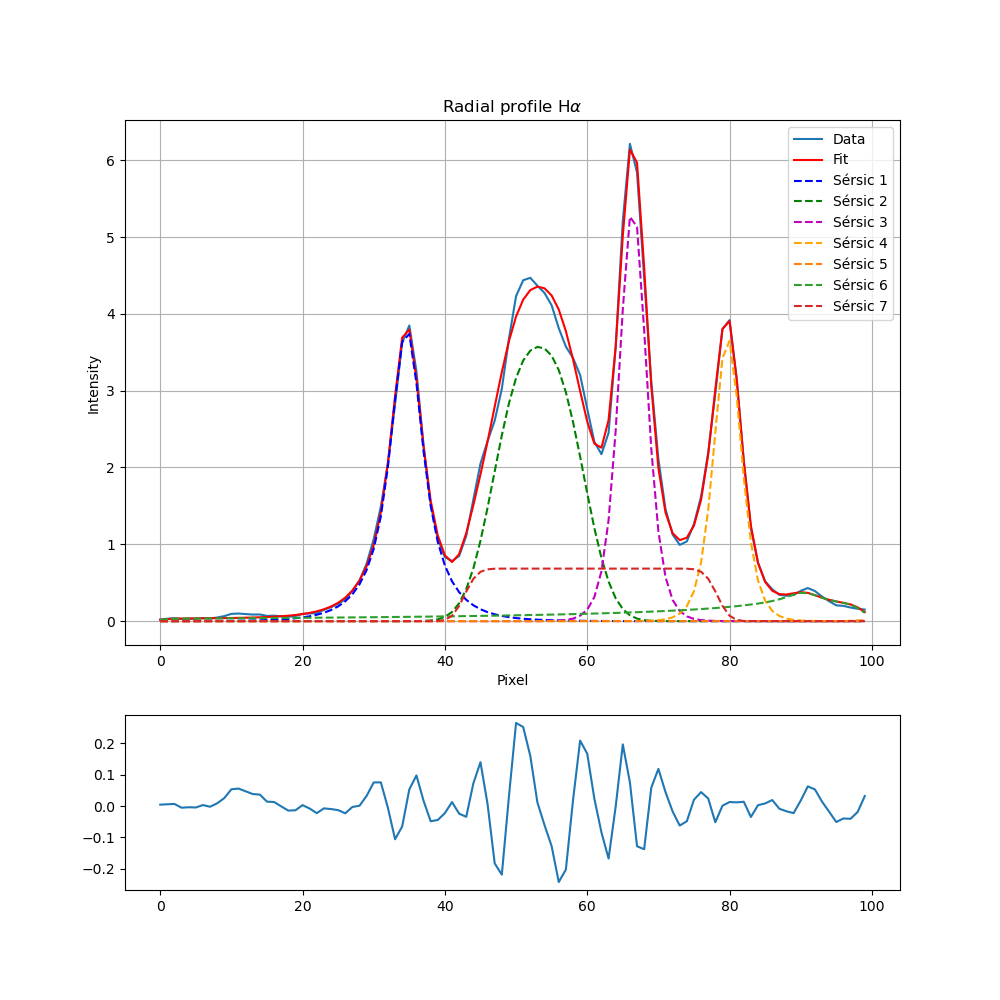

In [29]:
# Plots:
params_curve_7, covariance_7 = curve_fit(lambda x, *params: model_convolved(x, *params), x_axes, radial_profile_HA, p0=best_params7, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

chi_quadr[6], red_chi[6] = save_params(params_curve_7, covariance_7, radial_profile_HA, radial_profile_error_HA, x_axes, 7, 
                                       line_name="Seven", output_prefix="fit")

aic[6] = AIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
bic[6] = BIC(x_axes, radial_profile_HA, chi_quadr[6], params_curve_7)
print(aic[6], chi_quadr[6], bic[6], len(best_params7))

# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_7)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[12:16]), color='orange', linestyle='--', label='Sérsic 4')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[16:20]),  linestyle='--', label='Sérsic 5')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[20:24]),  linestyle='--', label='Sérsic 6')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_7[24:28]),  linestyle='--', label='Sérsic 7')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x_axes, radial_profile_HA - y_fit)

plt.savefig('AIC_7', bbox_inches='tight')

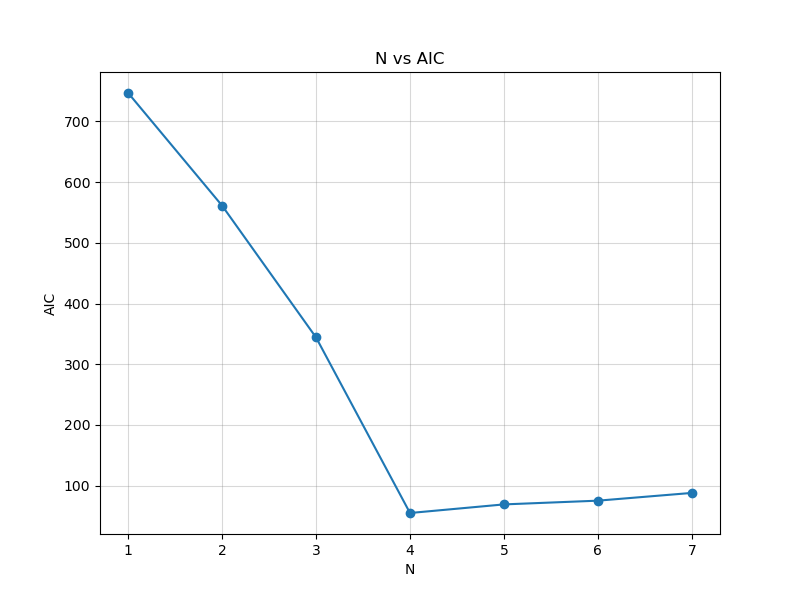

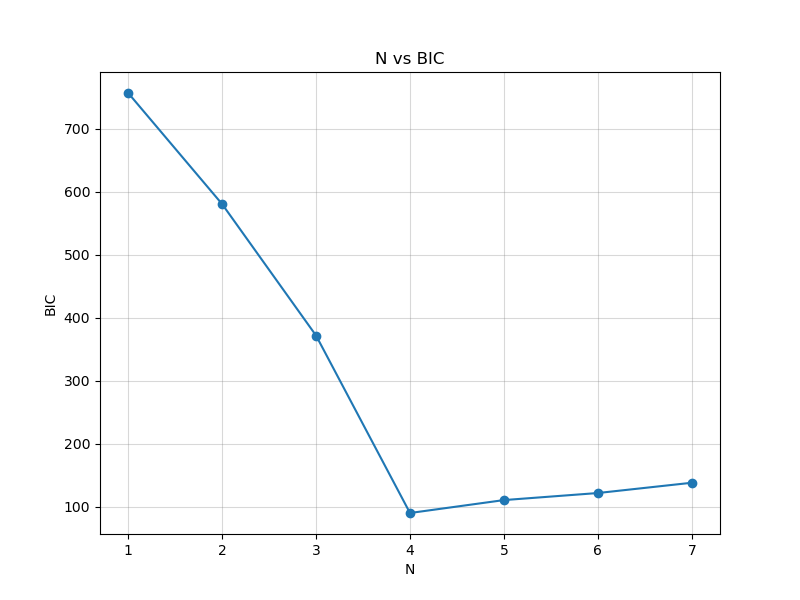

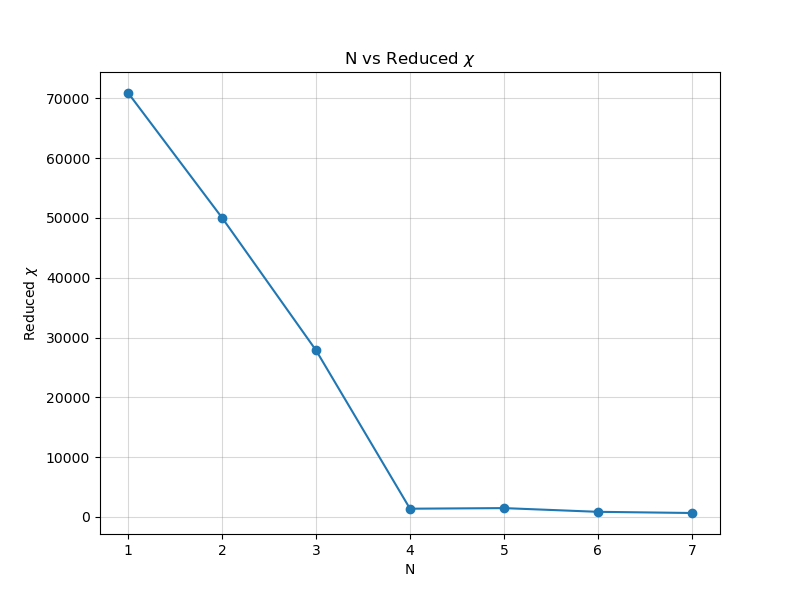

In [30]:
#Plot AIC vs N 
n = [1, 2, 3, 4, 5, 6, 7]

fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('AIC')
ax1.set_title('N vs AIC')
ax1.plot(n, aic, marker = 'o')
plt.savefig('AIC_vs_N', bbox_inches='tight')
np.savetxt('AIC', aic)
np.savetxt('Reduced_chi', red_chi)

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('BIC')
ax2.set_title('N vs BIC')
ax2.plot(n, bic, marker = 'o')
plt.savefig('BIC_vs_N', bbox_inches='tight')
np.savetxt('BIC', aic)

fig3 = plt.figure(figsize=(8,6))
ax3 = fig3.gca()
ax3.grid(alpha=0.3, c = 'grey')
ax3.set_xlabel('N')
ax3.set_ylabel('Reduced $\chi$')
ax3.set_title('N vs Reduced $\chi$')
ax3.plot(n, red_chi, marker = 'o')
plt.savefig('Reduced_chi_vs_N', bbox_inches='tight')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_14004\1257891682.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig2 = plt.figure(figsize=(8,6))


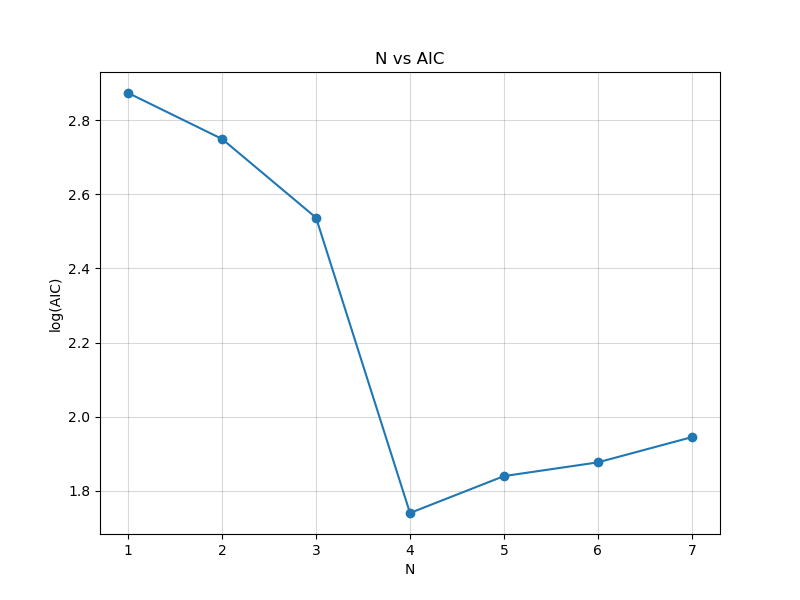

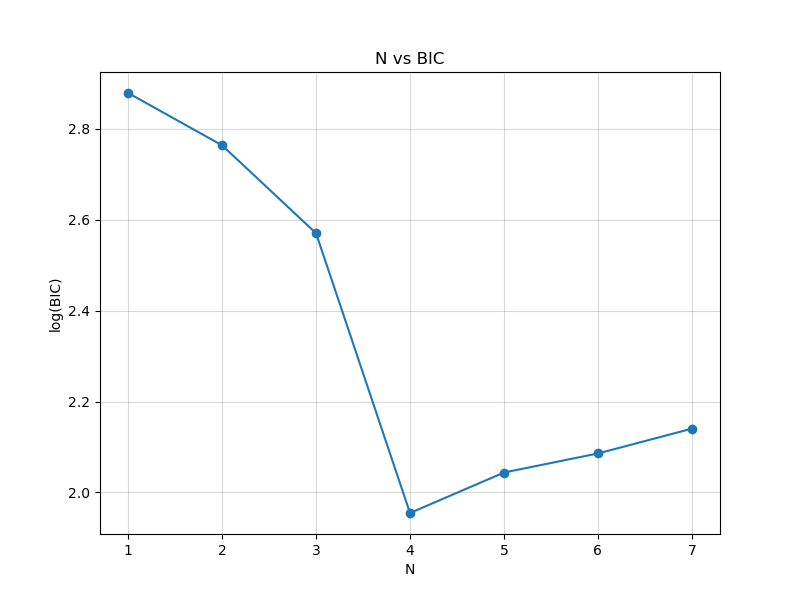

In [31]:
fig1 = plt.figure(figsize=(8,6))
ax1 = fig1.gca()
ax1.grid(alpha=0.3, c = 'grey')
ax1.set_xlabel('N')
ax1.set_ylabel('log(AIC)')
ax1.set_title('N vs AIC')
ax1.plot(n, np.log10(aic), marker = 'o')
plt.savefig('AIC_vs_N_log', bbox_inches='tight')

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(alpha=0.3, c = 'grey')
ax2.set_xlabel('N')
ax2.set_ylabel('log(BIC)')
ax2.set_title('N vs BIC')
ax2.plot(n, np.log10(bic), marker = 'o')
plt.savefig('BIC_vs_N_log', bbox_inches='tight')